
# Optimisation results analysis
We will conduct a turbine-level analysis to understand how each of the optimisers work.

The case study used is Horns Rev 1.

In [1]:
import numpy as np
import seaborn
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import json
from typing import Dict
import sys
import pandas as pd

plt.style.use('default')

BASELINE_HR1_POWER = 63.492160278290314  # megawatts of unyawed HR1
KEYS = ["best_yaw", "per_case_power_MW", "wind_dir_deg", "wind_speed", "weights"]

### Load the necessary .npz files


In [2]:
# Serial-Refine
sr_data = np.load(rf".\yaw_serial_hr1\20260309_172931\arrays.npz")

# SLSQP
slsqp_data = np.load(rf".\yaw_slsqp_hr1\20260309_173450\arrays.npz")

# Bayex
bo_data = np.load(rf".\yaw_bayes_hr1\20260310_095506\arrays.npz")

In [3]:
sr_data = {key: sr_data[key] for key in KEYS}
slsqp_data = {key: slsqp_data[key] for key in KEYS}
bo_data = {key: bo_data[key] for key in KEYS}

# Convert degrees to radians
sr_data['best_yaw'] = np.rad2deg(sr_data['best_yaw'])
slsqp_data['best_yaw'] = np.rad2deg(slsqp_data['best_yaw'])
bo_data['best_yaw'] = np.rad2deg(bo_data['best_yaw'])

sr_yaw = sr_data['best_yaw']
slsqp_yaw = slsqp_data['best_yaw']
bo_yaw = bo_data['best_yaw']

sr_opt_power = sr_data['per_case_power_MW'][0]
slsqp_opt_power = slsqp_data['per_case_power_MW'][0]
bo_opt_power = bo_data['per_case_power_MW'][0]

## We can use FLORIS to plot wind turbine yaw angles

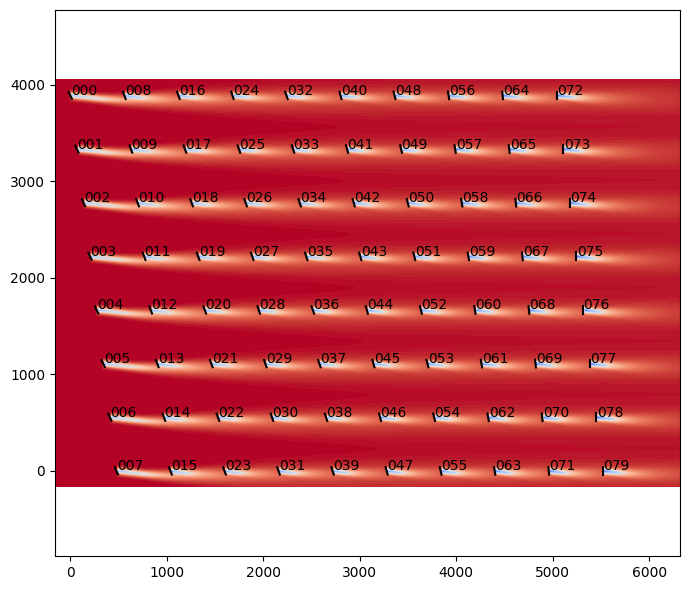

In [7]:
import floris.flow_visualization as flowviz
import floris.layout_visualization as layout_viz
from floris import FlorisModel
import yaml

def loader_with_include(path):
    """Custom YAML loader to support the !include tag."""
    class IncludeLoader(yaml.SafeLoader):
        def __init__(self, stream):
            self._root = os.path.split(stream.name)[0]
            super(IncludeLoader, self).__init__(stream)

    def construct_include(loader, node):
        filename = os.path.join(loader._root, loader.construct_scalar(node))
        with open(filename, 'r') as f:
            return yaml.load(f, IncludeLoader)

    yaml.add_constructor('!include', construct_include, IncludeLoader)
    return IncludeLoader

hr1_yaml = rf"..\data\horn\gch.yaml"
with open(hr1_yaml, 'r') as f:
    hr1_params = yaml.load(f, loader_with_include(hr1_yaml))

lx = hr1_params['farm']['layout_x']
ly = hr1_params['farm']['layout_y']

plt.style.use('default')

def plot_yaw_angles(yaw_angles: np.ndarray):
    fmodel = FlorisModel(hr1_yaml)
    fmodel.set(yaw_angles=yaw_angles)
    fmodel.run()

    fig, ax = plt.subplots(figsize=(7, 6))

    horizontal_plane = fmodel.calculate_horizontal_plane(height=90.0, x_resolution=400, y_resolution=400)
    flowviz.visualize_cut_plane(horizontal_plane, ax=ax, levels=150)
    layout_viz.plot_turbine_rotors(fmodel, ax=ax, yaw_angles=yaw_angles)
    layout_viz.plot_turbine_labels(fmodel, ax=ax)

    plt.tight_layout()
    plt.show()

    return fig, ax

fig, ax = plot_yaw_angles(sr_yaw)

In [ ]:
plot_yaw_angles(slsqp_yaw)

# SLSQP analysis

## JSONL data

Let's have a look at 3 turbines and see how their yaw angles change individually. We can separate the rows of turbines into 3

In [11]:
N = 80
def extract_yaw_angles(opt_path: str,
                      ) -> Dict:

    opt_log = []
    with open(opt_path, "r") as f:
        for line in f:
            opt_log.append(json.loads(line))

    n_iters = len(opt_log)
    opt_yaws = {}

    # Extract yaw angles per turbine
    for t in range(N):
        opt_yaws[f"T{t}"] = []
        for i in range(n_iters):
            opt_yaws[f"T{t}"].append(opt_log[i]['yaw_angles_deg'][t])

    return opt_yaws

# Get the indices of the 3 most upstream turbines of the first row
t1, t8, t16 = 0, 8, 16
t24 = 24

slsqp_yaws = extract_yaw_angles(rf"./yaw_slsqp_hr1/20260309_220224/opt_log.jsonl")

# slsqp_r1 = slsqp_loss[50:251]
# slsqp_r2 = slsqp_loss[251:452]
# slsqp_r3 = slsqp_loss[452:656]
# Observe how they behave through a 3D scatter plot + individual iteration steps
def turbine_behaviour(yaws_dict: dict,
                      optimiser_name: str,
                      i1: int,
                      i2: int,
                      i3: int):
    fig, ax = plt.subplots(1, 3, figsize=(17, 6))

    # ====================================================================================
    # Restart 1 plot
    # ax[0].plot(yaws_dict[f"T{i1}"][50:251], label=f"T{i1}")
    # ax[0].plot(yaws_dict[f"T{i2}"][50:251], label=f"T{i2}")
    # ax[0].plot(yaws_dict[f"T{i3}"][50:251], label=f"T{i3}")
    ax[0].plot(yaws_dict[f"T{i1}"], label=f"T{i1}")
    ax[0].plot(yaws_dict[f"T{i2}"], label=f"T{i2}")
    ax[0].plot(yaws_dict[f"T{i3}"], label=f"T{i3}")
    ax[0].legend()
    ax[0].set_ylabel("Yaw angle (degrees)")
    ax[0].set_xlabel("Iteration count")
    ax[0].set_title("Restart 1")


    # ax[0][1].scatter(yaws_dict[f"T{i1}"][50:251], yaws_dict[f"T{i2}"][50:251], yaws_dict[f"T{i3}"][50:251], c=np.arange(len(yaws_dict[f"T{i1}"][50:251])), cmap='viridis')
    # ax[0][1].set_xlabel(f"T{i1}")
    # ax[0][1].set_ylabel(f"T{i2}")
    # ax[0][1].set_zlabel(f"T{i3}")

    if not optimiser_name == "Bayesian optimisation":
        # ====================================================================================
        # Restart 2 plot
        ax[1].plot(yaws_dict[f"T{i1}"][251:452], label=f"T{i1}")
        ax[1].plot(yaws_dict[f"T{i2}"][251:452], label=f"T{i2}")
        ax[1].plot(yaws_dict[f"T{i3}"][251:452], label=f"T{i3}")
        # ax[1][0].plot(yaws_dict[f"T{i1}"], label=f"T{i1}")
        # ax[1][0].plot(yaws_dict[f"T{i2}"], label=f"T{i2}")
        # ax[1][0].plot(yaws_dict[f"T{i3}"], label=f"T{i3}")
        ax[1].legend()
        ax[1].set_ylabel("Yaw angle (degrees)")
        ax[1].set_xlabel("Iteration count")
        ax[1].set_title("Restart 2")

        # ax[1][1].scatter(yaws_dict[f"T{i1}"][251:452], yaws_dict[f"T{i2}"][251:452], yaws_dict[f"T{i3}"][251:452], c=np.arange(len(yaws_dict[f"T{i1}"][251:452])), cmap='viridis')
        # ax[1][1].set_xlabel(f"T{i1}")
        # ax[1][1].set_ylabel(f"T{i2}")
        # ax[1][1].set_zlabel(f"T{i3}")

        # # ====================================================================================
        # Restart 3 plot
        ax[2].plot(yaws_dict[f"T{i1}"][452:656], label=f"T{i1}")
        ax[2].plot(yaws_dict[f"T{i2}"][452:656], label=f"T{i2}")
        ax[2].plot(yaws_dict[f"T{i3}"][452:656], label=f"T{i3}")
        # ax[2][0].plot(yaws_dict[f"T{i1}"], label=f"T{i1}")
        # ax[2][0].plot(yaws_dict[f"T{i2}"], label=f"T{i2}")
        # ax[2][0].plot(yaws_dict[f"T{i3}"], label=f"T{i3}")
        ax[2].legend()
        ax[2].set_ylabel("Yaw angle (degrees)")
        ax[2].set_xlabel("Iteration count")
        ax[2].set_title("Restart 3")

        # ax[2][1].scatter(yaws_dict[f"T{i1}"][452:656], yaws_dict[f"T{i2}"][452:656], yaws_dict[f"T{i3}"][452:656], c=np.arange(len(yaws_dict[f"T{i1}"][452:656])), cmap='viridis')
        # ax[2][1].set_xlabel(f"T{i1}")
        # ax[2][1].set_ylabel(f"T{i2}")
        # ax[2][1].set_zlabel(f"T{i3}")

    plt.suptitle(f"{optimiser_name} Turbine angles (degrees)")
    plt.tight_layout()
    plt.show()


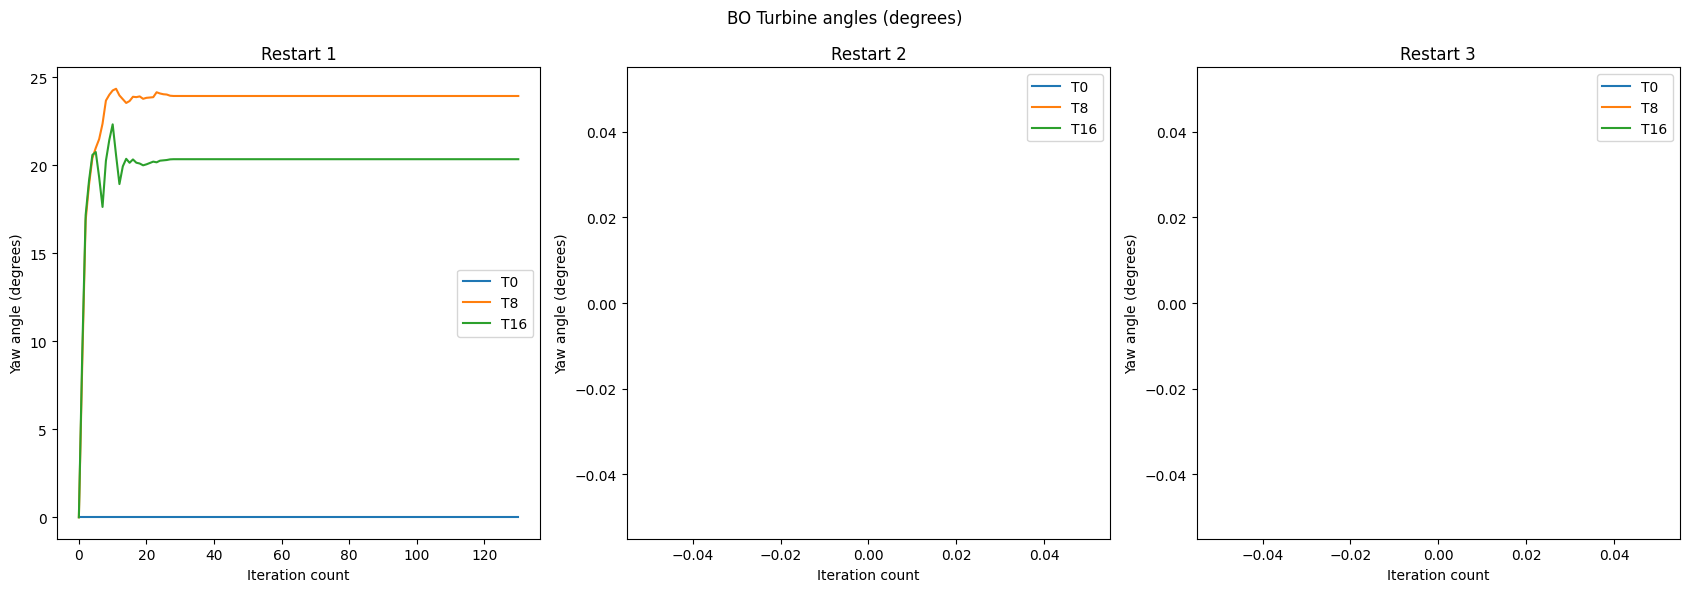

In [12]:
turbine_behaviour(slsqp_yaw_ref0, "BO", t1, t8, t16)

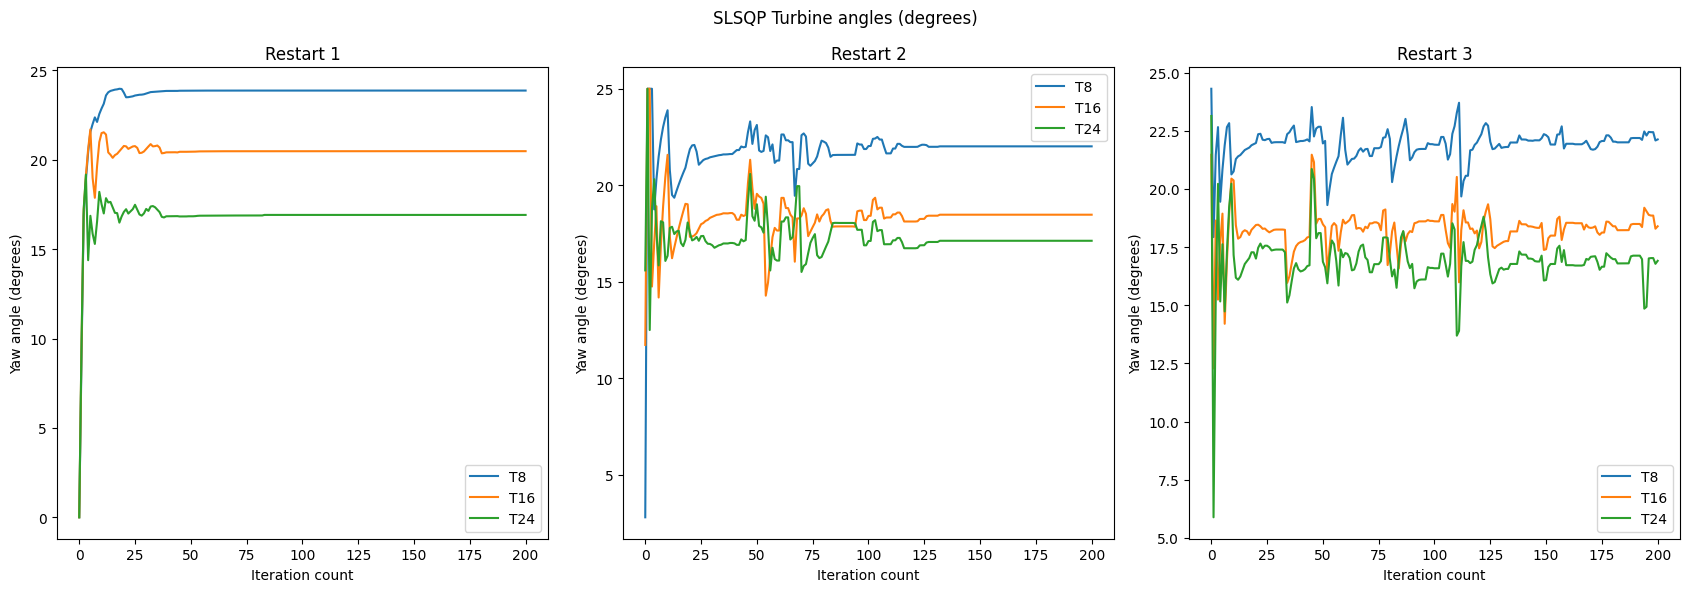

In [36]:
turbine_behaviour(slsqp_yaws, "SLSQP", t8, t16, t24)

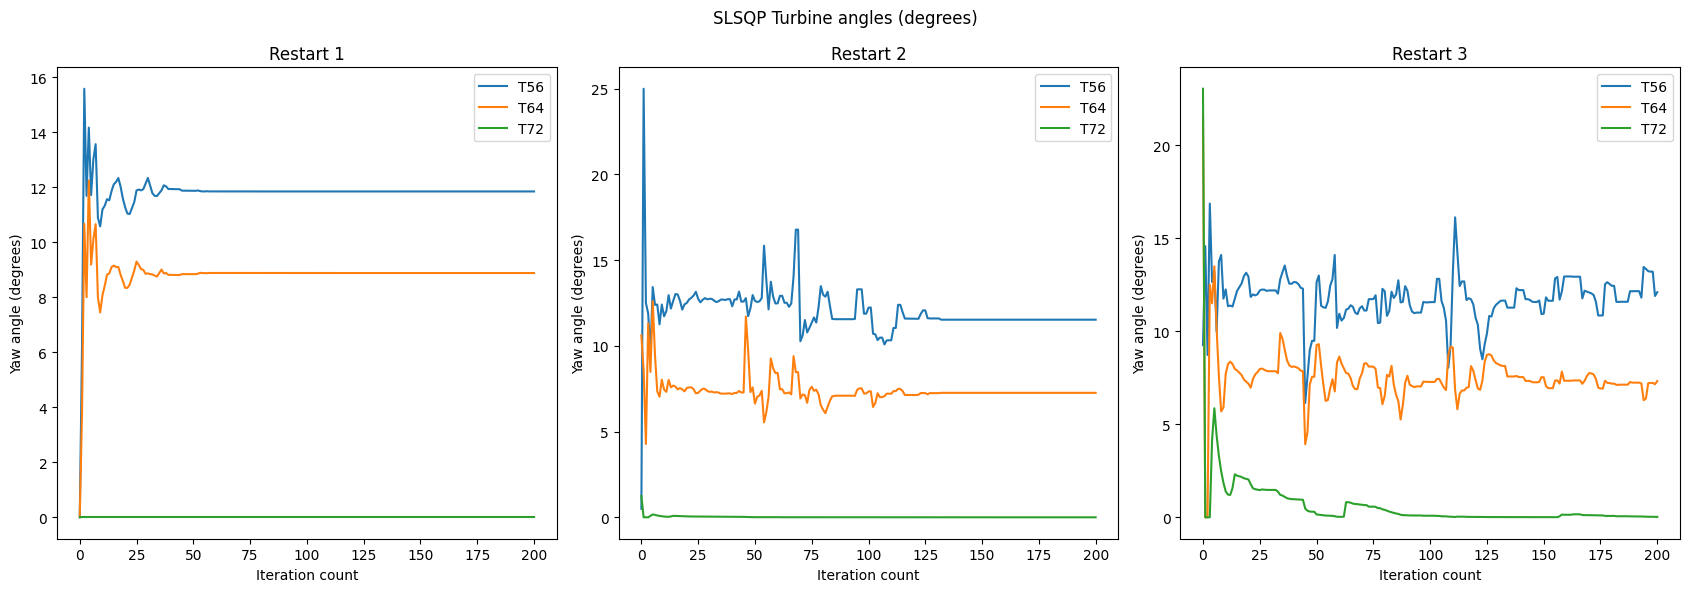

In [37]:
# A downstream row of 3~
t56, t64, t72 = 56, 64, 72
turbine_behaviour(slsqp_yaws, "SLSQP", t56, t64, t72)

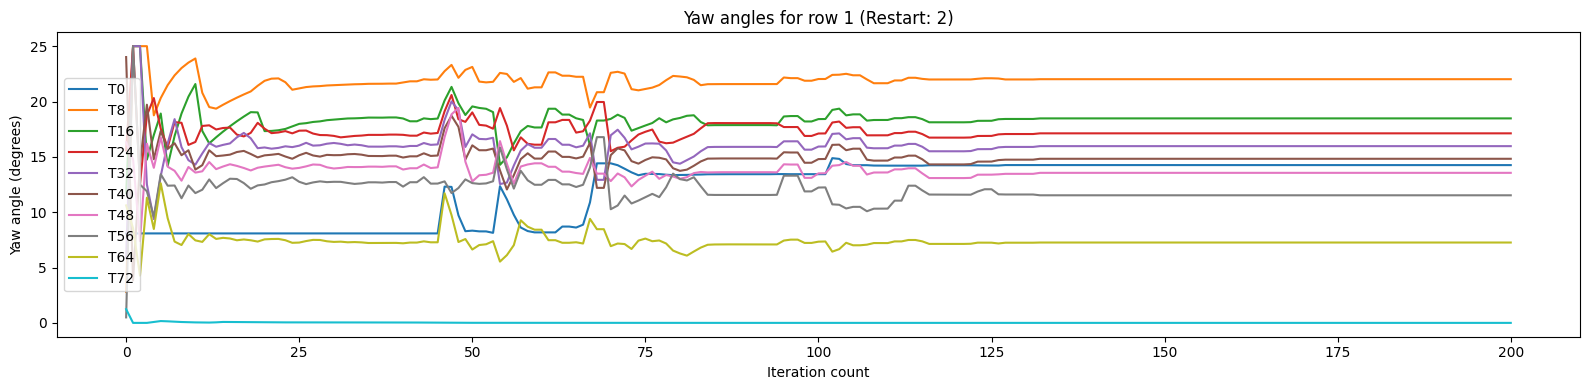

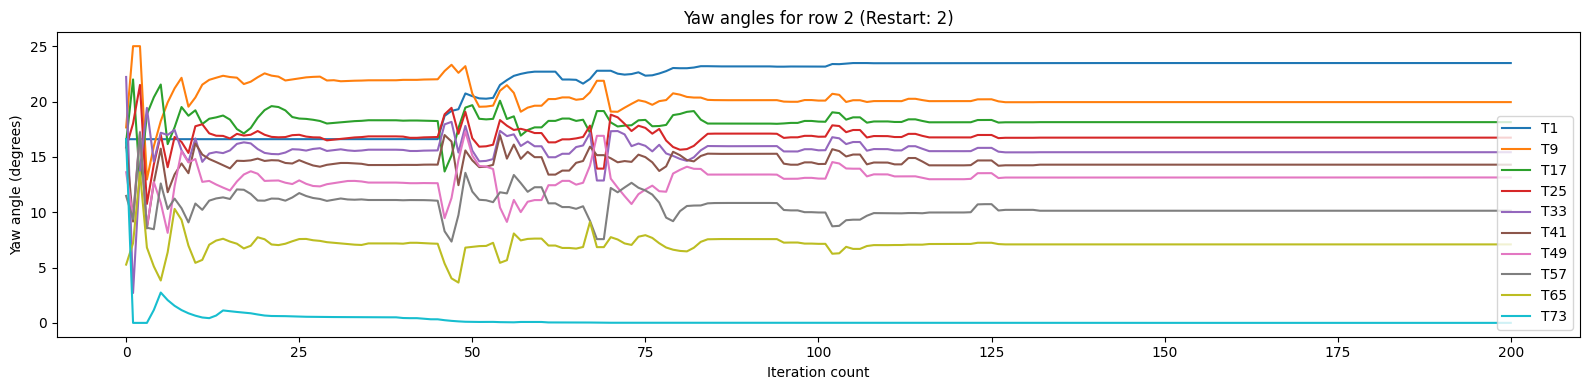

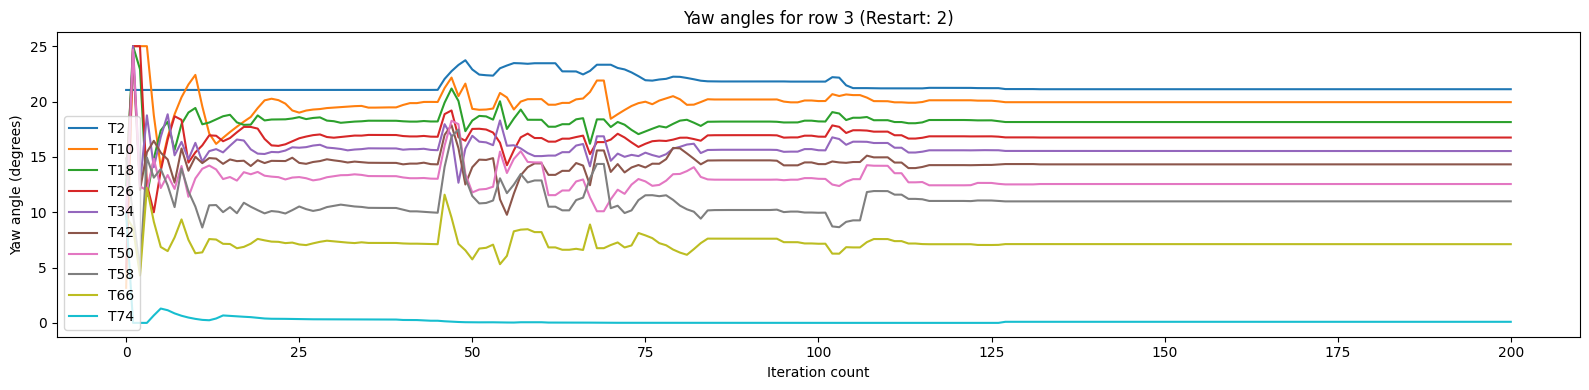

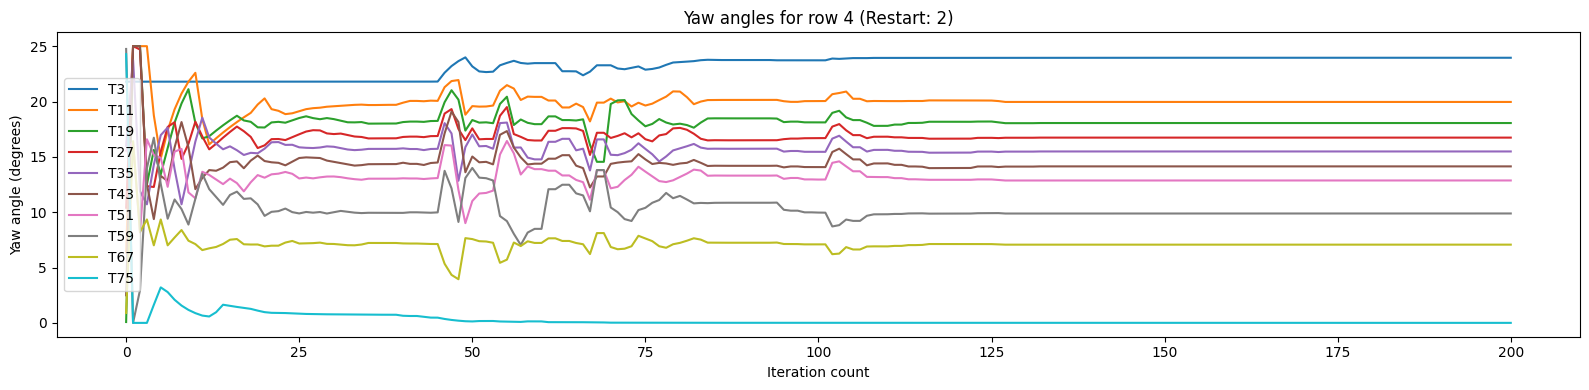

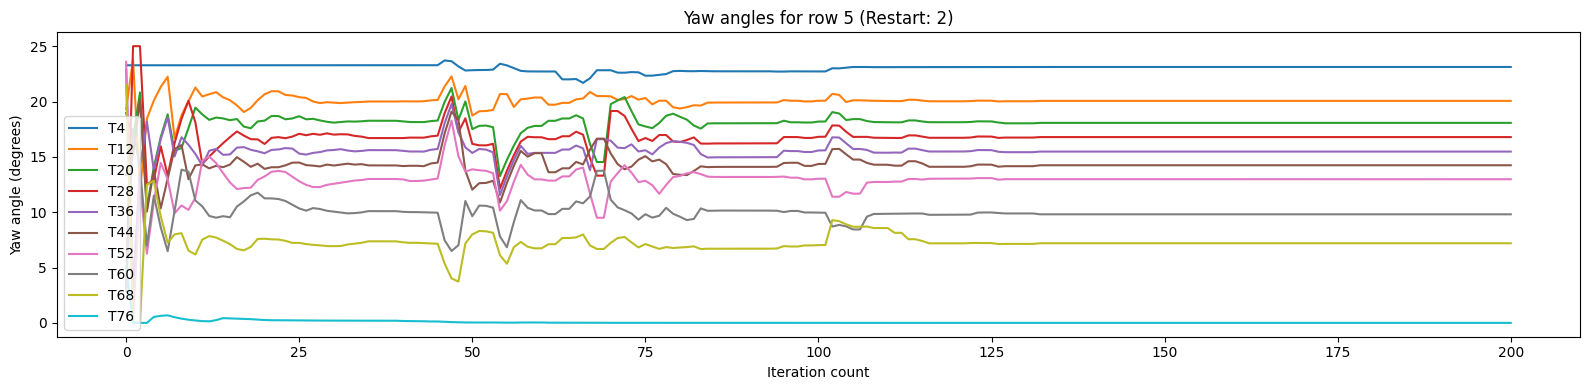

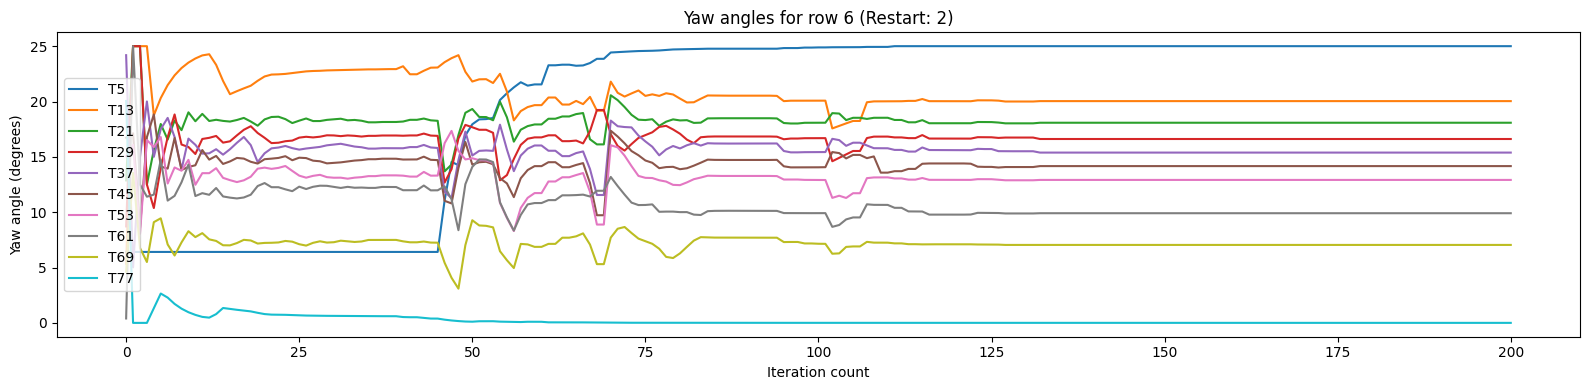

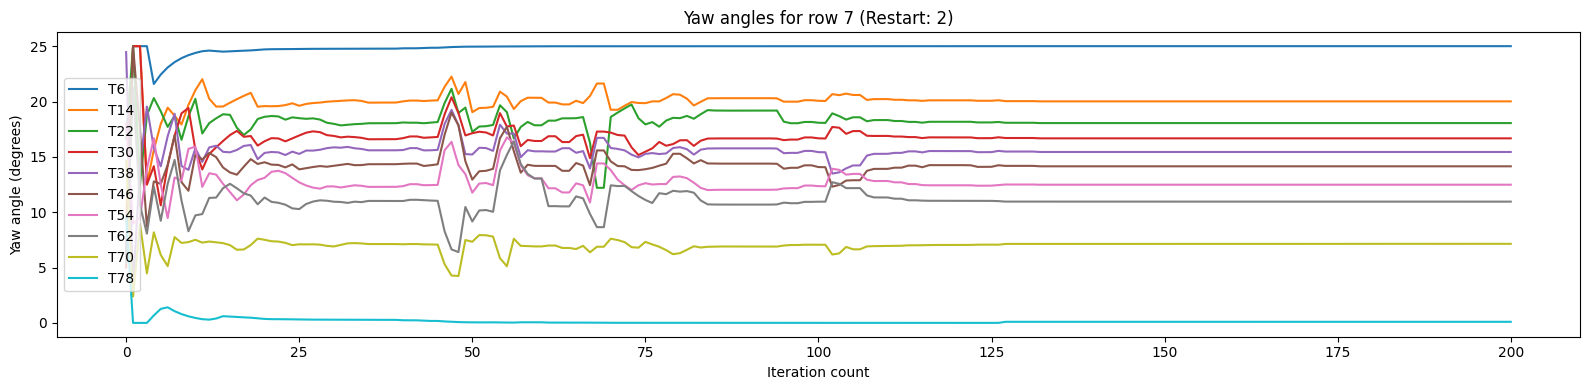

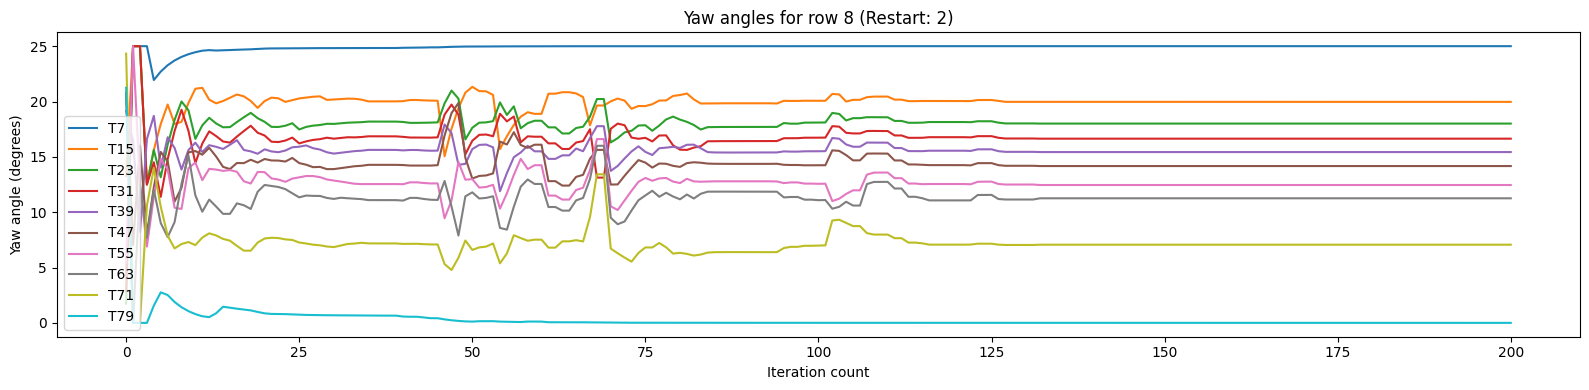

In [81]:
# Plot showing how yaw angles change for one entire row
def yaw_angle_per_row(opt_yaws: dict,
                      row_number: int,
                      restart: int):
    if row_number == 0:
        raise ValueError("Please enter a valid row number (1-8)")

    match restart:
        case 3:
            start_idx, end_idx = 452, 656
        case 2:
            start_idx, end_idx = 251, 452
        case _:
            start_idx, end_idx = 50, 251


    plt.figure(figsize=(16, 4))
    # 10 turbines per row
    for i in range(10):
        plt.plot(opt_yaws[f"T{(row_number - 1) + (8 * i)}"][start_idx:end_idx], label=f"T{(row_number - 1) + (8 * i)}")

    plt.xlabel("Iteration count")
    plt.ylabel("Yaw angle (degrees)")
    plt.title(f"Yaw angles for row {row_number} (Restart: {restart})")
    plt.tight_layout()
    plt.legend()
    plt.show()

for i in range(1, 9):
    yaw_angle_per_row(slsqp_yaws, i, 2)



# Bayex analysis

In [82]:
# LCB acquisition
# bo_yaws = extract_yaw_angles(rf".\yaw_bayes_hr1\20260310_095506\opt_log.jsonl")  # LCB acquisition
bo_yaws = extract_yaw_angles(rf".\yaw_bayes_hr1\20260316_101523\opt_log.jsonl")  # EI acquisition



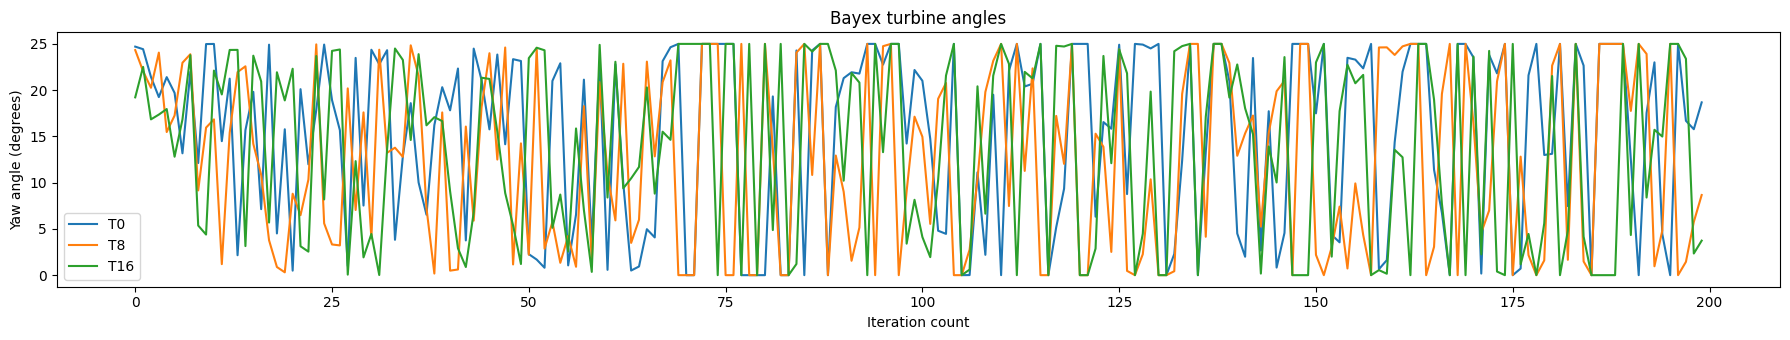

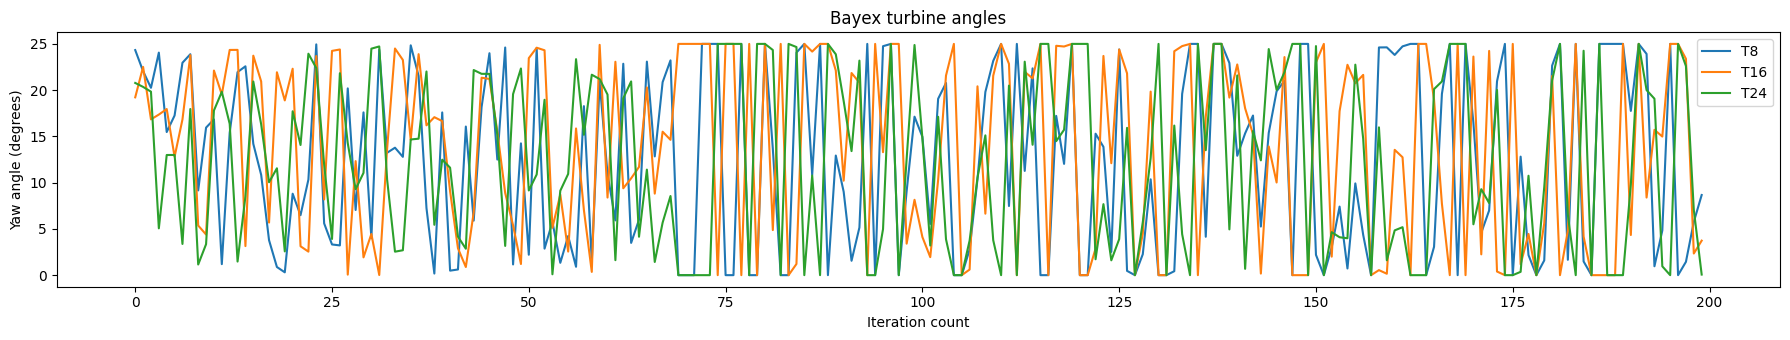

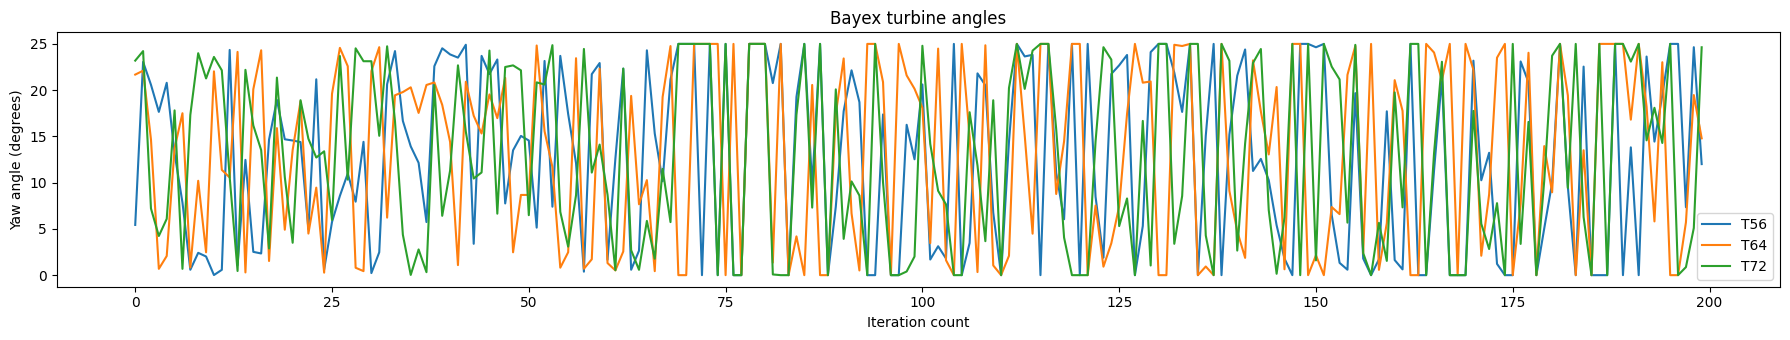

In [83]:
def plot_bo_yaws(yaws_dict: dict,
                 i1: int,
                  i2: int,
                  i3: int, ):
    plt.figure(figsize=(18, 3.5))

    plt.plot(bo_yaws[f"T{i1}"], label=f"T{i1}")
    plt.plot(bo_yaws[f"T{i2}"], label=f"T{i2}")
    plt.plot(bo_yaws[f"T{i3}"], label=f"T{i3}")
    plt.xlabel("Iteration count")
    plt.ylabel("Yaw angle (degrees)")
    plt.title("Bayex turbine angles")

    plt.legend()
    plt.tight_layout()
    plt.show()

plot_bo_yaws(bo_yaws, t1, t8, t16)
plot_bo_yaws(bo_yaws, t8, t16, t24)
plot_bo_yaws(bo_yaws, t56, t64, t72)

## Rule of thumb
For well-ordered farm layouts like Horns Rev 1, it is intuitive that the global solution generally follows a structure where turbines have a decreasing yaw the further downstream they are. It follows that the most downstream turbines should not be yawed at all, to maximise their energy extraction from the wind.

To see if the Bayesian optimiser can implicitly find this rule (but not necessarily 'learn' it), we can plot the angle differences per iteration i.e. T0 - T8, and T8 - T16. We are looking for a trend where both are positive.

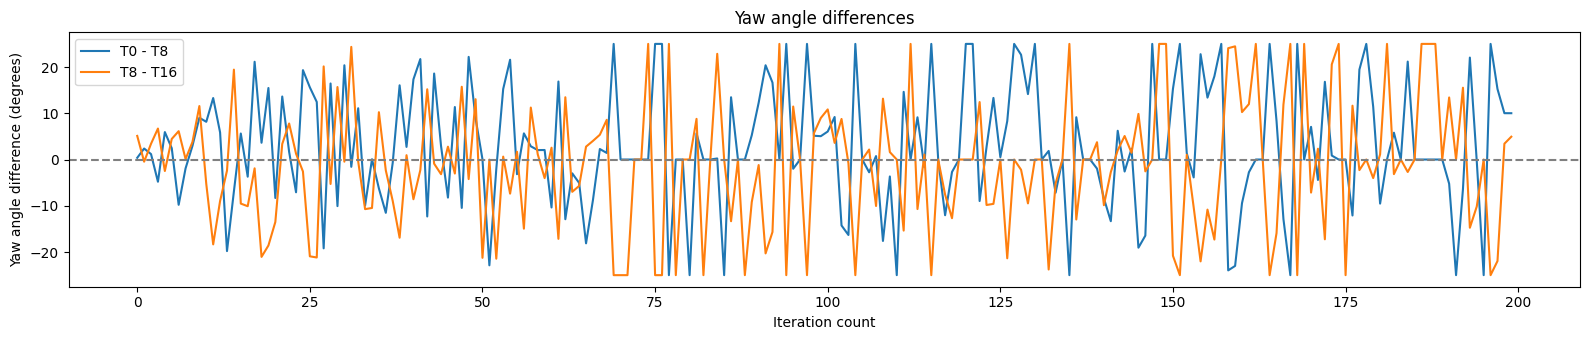

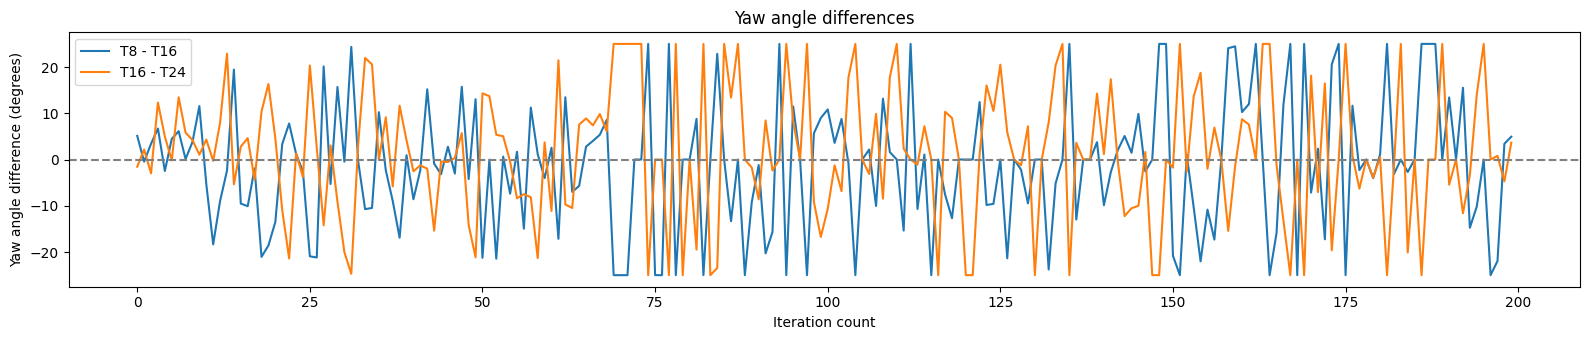

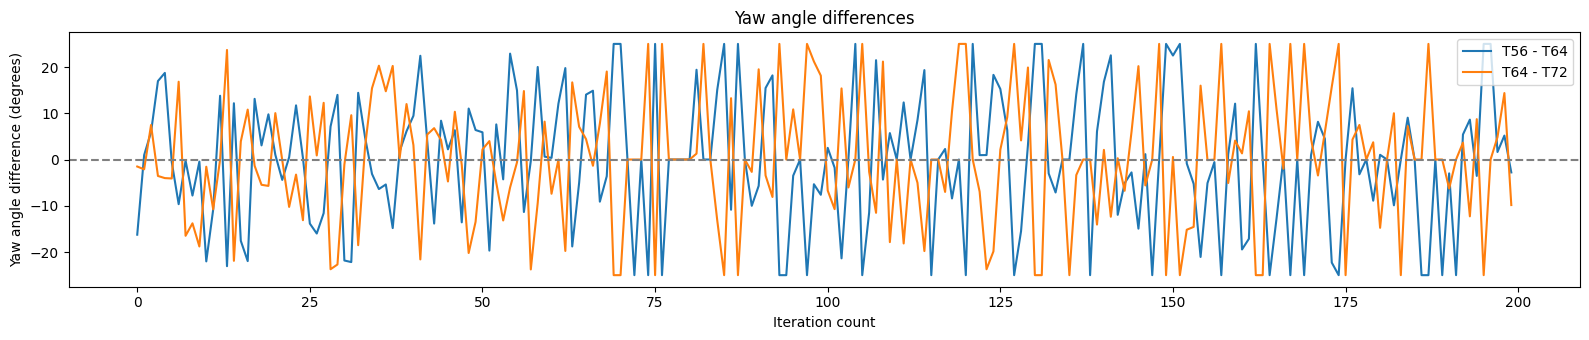

In [85]:
def plot_yaw_diff(yaws_dict: dict,
                  i1: int,
                  i2: int,
                  i3: int):
    diff1 = np.array(yaws_dict[f"T{i1}"]) - np.array(yaws_dict[f"T{i2}"])
    diff2 = np.array(yaws_dict[f"T{i2}"]) - np.array(yaws_dict[f"T{i3}"])

    plt.figure(figsize=(16, 3.5))
    plt.plot(diff1, label=f"T{i1} - T{i2}")
    plt.plot(diff2, label=f"T{i2} - T{i3}")
    plt.axhline(y=0, color='gray', linestyle='--')

    plt.xlabel("Iteration count")
    plt.ylabel("Yaw angle difference (degrees)")
    plt.title(f"Yaw angle differences")

    plt.legend()
    plt.tight_layout()
    plt.show()

plot_yaw_diff(bo_yaws, t1, t8, t16)
plot_yaw_diff(bo_yaws, t8, t16, t24)
plot_yaw_diff(bo_yaws, t56, t64, t72)

## Analysing the effects of restarts on SLSQP

In [40]:
ref_paths[1]

IndexError: list index out of range

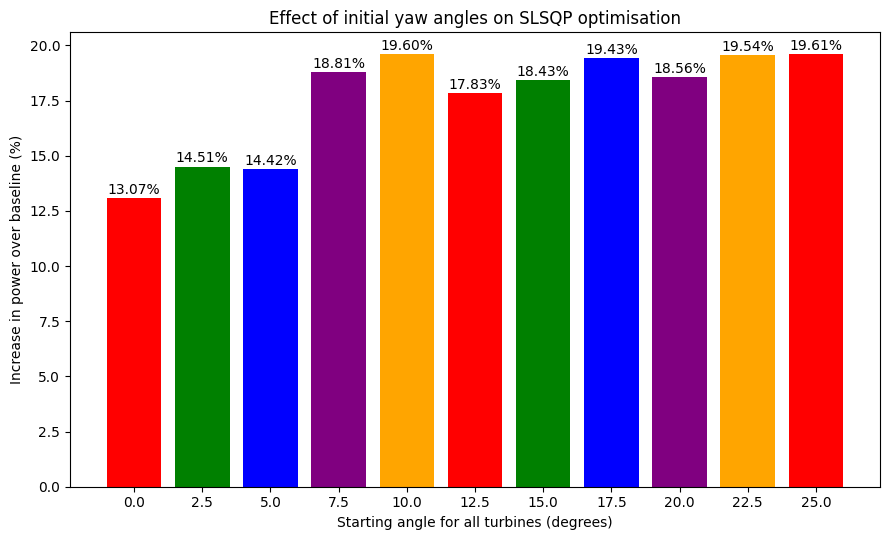

In [59]:
ref_paths = [rf".\yaw_slsqp_hr1\ref{i+1}" for i in range(0, 11)]
slsqp_yaw_refs = {f"ref{i+1}": extract_yaw_angles(ref_paths[i] + "/opt_log.jsonl") for i in range(0, 11)}
ref_key = {1: 0.0, 2: 2.5, 3: 5.0, 4: 7.5, 5: 10.0, 6: 12.5, 7: 15.0, 8: 17.5, 9: 20.0, 10: 22.5, 11: 25.0}


def get_metadata(path: list[str]):#
    metadata = []
    for p in path:
        with open(f'{p}\meta.json', 'r') as f:
            md = json.load(f)
        metadata.append(md)
    return metadata

metadata = get_metadata(ref_paths)

metric = 'power_increase_pct'
baseline_power = metadata[0]['baseline_power_MW']

opt_powers = {f"ref{i+1}": metadata[i][metric] for i in range(0, 11)}

ref0_opt_power = metadata[0][metric]
ref125_opt_power = metadata[2][metric]
ref1_opt_power = metadata[1][metric]
ref2_opt_power = metadata[3][metric]

labels = ["0.0", "2.5", "5.0", "7.5", "10.0", "12.5", "15.0", "17.5", "20.0", "22.5", "25.0"]
values = [opt_powers['ref1'], opt_powers['ref2'], opt_powers['ref3'], opt_powers['ref4'], opt_powers['ref5'], opt_powers['ref6'], opt_powers['ref7'], opt_powers['ref8'], opt_powers['ref9'], opt_powers['ref10'], opt_powers['ref11']]
plt.figure(figsize=(9, 5.5))
bars = plt.bar(labels, values, color=['red', 'green', 'blue', 'purple', 'orange'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f"{yval:.2f}%", ha='center', va='bottom')
plt.xlabel("Starting angle for all turbines (degrees)")
plt.ylabel("Increase in power over baseline (%)")
# plt.tick_params("x", rotation=45)
plt.title("Effect of initial yaw angles on SLSQP optimisation")
plt.tight_layout()
plt.show()

